Tên: Nguyễn Trọng Phúc, MSSV: 2510194

In [7]:
import numpy as np

#BÀI 1: BIỂU DIỄN DỮ LIỆU THÀNH MA TRẬN & ĐỘ TƯƠNG ĐỒNG
# 1. Biến dữ liệu thành ma trận
cau = ["I like Artificial Intelligence", 
       "I love Machine Learning", 
       "Roblox is just so peak", 
       "ML IoT team is a group of good boi", 
       "AI is my favorite subject", 
       "Aram mayhem is trash but I still play it", 
       "I like listening to Car's Outside by James Arthur", 
       "Why AI is so hard bro"]

#bag of words
vocab = sorted({w for s in cau for w in s.lower().split()})
def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        v[vocab.index(w)] += 1
    return v

X = np.array([to_vector(s) for s in cau]) 
print(X.shape)


(8, 41)


1. Trả lời:

- Lệnh print(X.shape) sẽ in ra kích thước ma trận X là (8,41)
- 8 hàng đại diện cho 8 câu trong danh sách ban đầu, mỗi hàng là 1 vector biểu diễn cho 1 câu.
- 41 cột đại diện cho 41 từ được trích xuất từ danh sách "cau" và không có từ nào bị trùng. 
- Ở mỗi ô của mỗi hàng, giá trị sẽ là các số nguyên không âm tương ứng với tần suất xuất hiện của nó, nếu giá trị là 0 thì từ đó không xuất hiện trong câu, giá trị nguyên dương k thì từ đó xuất hiện k lần trong câu. 

In [8]:
#2. Phép toán cơ bản
mean = X.mean(axis = 0)
Xc = X - mean

print("Shape của mean: ", mean.shape)
print("Shape của X trước khi trừ: ", X.shape)
print("Shape của X sau khi trừ: ", Xc.shape)

Shape của mean:  (41,)
Shape của X trước khi trừ:  (8, 41)
Shape của X sau khi trừ:  (8, 41)


2. Trả lời:

Có thể thấy kích cỡ của X và Xc = X - mean vẫn giữ nguyên vì khi chương trình nhận thấy vector mean có cùng số cột với X thì chức năng broadcasting hoạt động, nó tự động sao chép vector mean thành 8 hàng sau đó thực hiện phép toán trừ ma trận như thường.

In [9]:
#3. Cosine similarity
def cosine_similarity(X, Y = None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis = 1, keepdims = True)
    Yn = Y / np.linalg.norm(Y, axis = 1, keepdims = True)
    return Xn @ Yn.T

matrix = cosine_similarity(X)
print("Ma trận tương đồng:\n", np.round(matrix, 3))

Ma trận tương đồng:
 [[1.    0.25  0.    0.    0.    0.167 0.333 0.   ]
 [0.25  1.    0.    0.    0.    0.167 0.167 0.   ]
 [0.    0.    1.    0.149 0.2   0.149 0.    0.365]
 [0.    0.    0.149 1.    0.149 0.111 0.    0.136]
 [0.    0.    0.2   0.149 1.    0.149 0.    0.365]
 [0.167 0.167 0.149 0.111 0.149 1.    0.111 0.136]
 [0.333 0.167 0.    0.    0.    0.111 1.    0.   ]
 [0.    0.    0.365 0.136 0.365 0.136 0.    1.   ]]


3. Trả lời:

Ma trận tương đồng là ma trận chỉ ra sự giống nhau của từng cặp câu trong ma trận X thông qua việc tính cos giữa 2 vector, ở trên, khi ta print ra ma trận tương đồng matrix thì thấy:
- Đường chéo chính toàn là số 1.0, vì nó tự so sánh nó với chính nó. Các câu không hề giống nhau thì sẽ có giá trị 0. Riêng ở ma trận này, các giá trị chỉ thuộc [0,1] vì X chỉ lưu các số không âm.
- Ma trận trên có tính đối xứng vì câu thứ i so với câu thứ j thì cũng giống như câu thứ j so với câu thứ i

In [10]:
#4. Truy vấn
def search(query, top_k = 3):
    q = np.array([to_vector(query)])
    sims = cosine_similarity(X, q).flatten()
    idx = np.argsort(sims)[-top_k:][::-1]
    return [(cau[i], round(float(sims[i]), 3)) for i in idx]

print(search("peak Roblox just is so"))

[('Roblox is just so peak', 1.0), ('Why AI is so hard bro', 0.365), ('AI is my favorite subject', 0.2)]


4. Trả lời:

Hàm search cho thấy sự tương đồng của câu đầu vào so với các câu trong danh sách "cau" bằng cách biến query thành vector q thông qua hàm to_vector ta đã xây dựng ở trên, sau đó so sánh nó với các vector trong ma trận X. Quan sát, ta thấy được:
- Nó sẽ liệt kê ra 3 trường hợp (vì top_k = 3) có sự tương đồng theo thứ tự từ cao xuống thấp theo điểm cosine similarity
- Với cách build hàm to_vector ở trên, khi ta input câu có chứa từ không nằm trong từ điển ta tạo ban đầu thì output sẽ bị lỗi. Ta có thể sửa lại bằng cách thêm điều kiện để nó bỏ qua các từ "lạ" đó bằng cách thêm "if w in vocab" ngay sau "for w in s.lower().split()".
- Có thể thấy, với việc xây dựng theo kiểu bag of words như trên chỉ đại khái cho ta hình dung được cách vector hóa một text và so sánh ý nghĩa 2 câu 1 cách sơ khai, trong thực tế, text có phần phức tạp hơn là phải đi qua 1 ma trận trọng số W do AI tự điều chỉnh. Tóm lại, cách so sánh trên chỉ quan tâm số từ xuất hiện

5. Trả lời: 

Ngoại trừ cặp câu đó và chính nó ra thì cặp "Roblox is just so peak" và "Why AI is so hard bro" là giống nhau nhất dựa trên điểm cosine similarity là 0.365, và có nhiều cặp khác biệt vì điểm cosine chỉ là 0., nhưng ta sẽ chú ý tới cặp câu: "I like Artificial Intelligence" và "AI is my favorite subject" có điểm cosine là 0 trong khi nghĩa giống nhau.

Có thể thấy, nó không đúng về mặt trực giác trên đa số trường hợp, vì rõ ràng trong 2 câu có điểm cosine là 0.365 ở trên, 1 câu nói về tựa game Roblox, 1 câu lại nói về AI, nghĩa hoàn toàn khác nhau, trong khi với ví dụ cặp câu còn lại ở trên, cả 2 đều nói là môn học yêu thích là AI nhưng chương trình cho ra điểm cosine là 0 tức là không hề liên quan nhau. Như đã nói ở câu 4, hàm search chỉ tìm sự tương đồng thông qua từ điển nó đã tạo ra, nó chỉ so sánh dựa trên sự xuất hiện của từ chứ không hiểu nghĩa như cách con người hiểu. 

In [11]:
#BÀI 2: BIẾN ĐỔI TUYẾN TÍNH & SVD
#2. Giảm chiều bằng SVD
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
coords = U[:, :2] * S[:2]

2. Trả lời:

Lệnh np.linalg.svd sẽ phân tích Xc thành dạng U @ S @ V.T. Theo đó, nó chiếu tập dữ liệu 41 chiều lên mặt phẳng 2D được định hình bởi 2 hướng chứa lượng thông tin biến thiên mạnh nhất ở dữ liệu gốc, tương ứng với 2 giá trị kỳ dị lớn nhất trong ma trận S. Nói cách khác, SVD cho phép chúng ta làm xấp xỉ ma trận hạng thấp. Bằng cách chỉ giữ lại các giá trị kỳ dị lớn nhất, chúng ta có thể giữ lại thông tin cốt lõi và loại bỏ dữ liệu nhiễu, ở đây ta lấy 2 chiều.

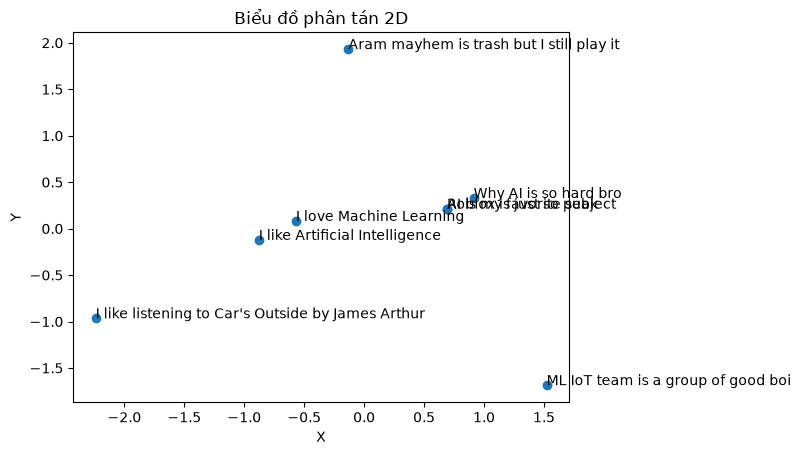

In [12]:
#3. Trực quan hóa
import matplotlib.pyplot as plt

x = coords[:, 0]
y = coords[:, 1]

plt.scatter(x,y)

#dùng loop để chạy từ đầu đến cuối câu để dán chữ vào đồ thị
for i in range(len(cau)):
    plt.annotate(cau[i], (x[i], y[i]))

plt.title("Biểu đồ phân tán 2D")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

3. Trả lời:

Hình vẽ thể hiện trực quan kết quả giảm chiều dữ liệu từ ma trận Xc sang mặt phẳng hình học 2D. Có thể thấy sự phân tán của các điểm và sự hình thành các cụm trên đồ thị, ví dụ như các câu có liên quan đến chủ đề về AI và ML sẽ gom thành cụm, có 3 điểm không liên quan lẫn nhau và cả AI, ML bị phân ra thành 3 nơi khác nhau dễ thấy. Điều đáng chú ý là 1 câu có khác biệt hoàn toàn về ngữ nghĩa là "Roblox is just so peak" lại bị lọt vào cụm về chủ đề AI, ML.

4. Trả lời:

Trong ví dụ các câu, dù ta thấy một số câu liên quan tới chủ đề Machine Learning và AI đều nằm khá gần nhau, tuy vậy, lại tồn tại ra 1 câu khác biệt hoàn toàn về ngữ nghĩa là: "Roblox is just so peak" cùng nằm trong cụm về chủ đề AI và ML. Hơn nữa, câu "Roblox is just so peak" và "AI is my favorite subject" còn bị trùng nhau. Lý giải cho việc này thì ta phân tích như sau:
- Trong không gian 41 chiều ban đầu, 2 câu này có cùng từ "is" nhưng lại khác các từ còn lại, tức là 2 vector này khác nhau. Nhưng khi sử dụng SVD để giảm xuống còn 2 chiều, 2 trục chính được chọn là những hướng có phương sai lớn nhất trong tập dữ liệu (cũng là các eigenvectors, đại diện cho các trục chính), cụ thể là các hướng bị chi phối bởi tần suất xuất hiện các từ như "i" và "is", trong khi các từ còn lại trong 2 câu thì lại đóng góp phương sai nhỏ và rất nhỏ, dẫn tới việc nó bị loại bỏ khi chỉ giữ 2 chiều, theo đó, 2 vector này có cùng 1 hình chiếu trên mặt phẳng 2D, hệ quả là 2 điểm này nằm trùng nhau.
- Điều này cũng cho thấy nhược điểm của SVD trên các tập nhỏ cũng như số chiều giảm xuống nhỏ, thêm nữa, chương trình phân cụm dựa trên sự trùng lặp mặt chữ theo thống kê, máy tính không hiểu ý nghĩa các câu từ như cách con người tư duy.